<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

### <font color= '#0400ffff'>**Methodology** </font><a class="anchor" id='top'></a>

- [1. Abstract](#1)
- [2. Import Libraries](#2)
- [3. Metadata](#3)
- [4. Import Datasets](#4)
    - [4.1 Define new index](#4_1)
- [5. Exploratory Data Analysis (EDA)](#5)
    - [5.1 Feature Relevance](#5_1)
    - [5.2 Sample Analysis](#5_2)
    - [5.3 Initial Data Structure](#5_3)
        - [5.3.1 Overview](#5_3_1)
        - [5.3.2 Missing Values Analysis](#5_3_2)
        - [5.3.3 Duplicates Analysis](#5_3_3)
    - [5.4 Univariate Analysis](#5_4)
        - [5.4.1 Unique Values](#5_4_1)
        - [5.4.2 Count Values](#5_4_2)
        - [5.4.3 Categorical Frequency](#5_4_3)
        - [5.4.4 Anomalies and Errors](#5_4_4)
        - [5.4.5 Target Feature Analysis (Price)](#5_4_5)
        - [5.4.6 Descriptive Statistics and Visualizations](#5_4_6)
    - [5.5 Bivariate Analysis](#5_5)
        - [5.5.1 Group By Analysis](#5_5_1)
        - [5.5.2 Correlation Matrix (Heatmap)](#5_5_2)
        - [5.5.3 Pairplot Analysis](#5_5_3)
    - [5.6 Multivariate Analysis](#5_6)
        - [5.6.1 Scatterplot 3D](#5_6_1)
        - [5.6.2 Scatter Matrix](#5_6_2)
- [6 End of the Notebook](#6)


<a class="anchor" id="1">

# **1. Abstract**

[Back to TOP](#top)
</a>

This project presents the development of a complete machine learning pipeline designed to predict car prices for Cars 4 You, with the purpose of supporting and accelerating the company’s vehicle evaluation process. Starting from the original 2020 dataset provided by the company, a full data exploration stage was conducted, addressing key data quality issues such as missing values, inconsistent formats, outliers, and incorrect data types. 

This notebook represents the start of our project. Throughout, we performed the Exploratory Data Analysis (EDA) process, which is based on analysing the dataset provided, addressing its quality, extracting insights and defining actionables for later cleaning in the Data Preprocessing phase.

During our analysis, we found missing values on all features, a small share of duplicates, a big quantity of misspellings on categorical features and some invalid data. Outliers are very common on most features and year, mileage and engineSize seem to be the most relevant features to predict the car's price.

<a class="anchor" id="2">

# **2. Import Libraries**

[Back to TOP](#top)
</a>

The following libraries are necessary for us to develop the analyses on this notebook. 

We also imported the **visualisations.py** file, where we defined useful functions to be used repetitively throughout the notebook.

In [2]:
# General Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For data manipulation and construction of a dataframe with different lists
from itertools import zip_longest

# Load Created Functions
import sys
sys.path.append("../")

from Source.visualizations import *

# Set random seed for reproducibility
np.random.seed(40111) 

<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#top)
</a>

Understanding the features is essential to interpret the data correctly and supports the subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and unit of measurement.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



<a class="anchor" id="4">

# **4. Import Datasets**

[Back to TOP](#top)
</a>

Here, we imported the csv files that contain the data and converted them into Pandas DataFrames.

In [3]:
sample = pd.read_csv('../../data/sample_submission.csv')
train = pd.read_csv('../../data/train.csv')
test = pd.read_csv('../../data/test.csv')

<a class="anchor" id="4">

## **4.1** Define new index

[Back to TOP](#top)
</a>

CarID was set as the index since it is the unique identifier of each individual car in all data sets.

In [4]:
sample.set_index('carID', inplace = True)
train.set_index('carID', inplace = True)
test.set_index('carID', inplace = True)

<a class="anchor" id="5">

# **5. Exploratory Data Analysis (EDA)**

[Back to TOP](#top)
</a>

In this phase, we explored the dataset and discovered inconsistencies, missing values, duplicated values, relationships and patterns. This analysis is crucial for the preprocessing stage where we'll need to correct all these issues to garantee a good overall performance of our models.

<a class="anchor" id="5_1">

## **5.1** Feature Relevance
[Back to TOP](#top)
</a>

Upon looking at the metadata, we can already disregard the feature `paintQuality%`, as it represents information provided by the mechanic, which is a step in the process we aim to substitute with this project.

We shall eliminate this feature in the feature selection process on the following notebook and disregard it from now on.

<a class="anchor" id="5_2">

## **5.2** Sample Analysis
[Back to TOP](#top)
</a>

In this step, we looked at the sample dataset. This dataset integrates the target feature, the price, which our predictions will aim to duplicate.

In [5]:
print("Initial Analysis of the Sample Submission Dataset")
print('')
print(sample.shape)
print('-----------------------')
print(sample.head())
print('-----------------------')
print(sample.tail())

Initial Analysis of the Sample Submission Dataset

(32567, 1)
-----------------------
         price
carID         
89856   851000
106581  514000
80886   323000
100174  921000
81376   620000
-----------------------
         price
carID         
105775  412000
81363   441000
76833   684000
91768   835000
99627     2000


From this small set of observations, we can already see a very wide range of values for the target, based on observations 100174 and 99627.

In [6]:
print("Continue to analyse the Sample Submission Dataset")
print('------------------------')
print('')
print(sample.info())
print('')
print('------------------------')
print(sample.describe())

Continue to analyse the Sample Submission Dataset
------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 32567 entries, 89856 to 99627
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   price   32567 non-null  int64
dtypes: int64(1)
memory usage: 508.9 KB
None

------------------------
               price
count   32567.000000
mean   498198.943716
std    288111.809635
min      1000.000000
25%    249000.000000
50%    501000.000000
75%    746000.000000
max    999000.000000


As stated before, the range of prices is very significant, we have 32567 entries with no missing values, and the data seems to follow a normal distribution, as the mean and the median are closely around 500000 and the first and thrid quartiles are around 250000 and 750000 respectively.

<a class="anchor" id="5_3">

## **5.3** Initial Data Structure
[Back to TOP](#top)
</a>

<a class="anchor" id="5_3_1">

### **5.3.1** Overview
[Back to TOP](#top)
</a>

In this section, we performed an initial exploration of the train and test datasets to understand their basic structure and content. We examined the first and last 10 rows of the data, checked general information about features, and reviewed summary statistics. This helped us get a first overview and detect any immediate issues before deeper analysis.

In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (75973, 13)
Test shape: (32567, 12)


The train dataset has one more feature (price) than the test dataset, as expected, as we will use it to train our models. It is also much larger than the test dataset, which is good for training.

In [8]:
train.head(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.000000,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.000000,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.000000,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.000000,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.000000,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
14704,BMW,3 Series,2014.0,8199,anual,101153.348285,Diesel,30.0,65.700000,2.0,74.0,0.000000,0.0
6924,Audi,A3,2017.0,16089,Manual,21396.000000,Petrol,20.0,60.100000,1.4,75.0,4.000000,0.0
50783,Skoda,Octavia,2017.0,7500,Manual,116750.000000,Diesel,145.0,68.900000,1.6,59.0,4.000000,0.0
67071,VW,Passat,2017.0,15999,Semi-Auto,30339.000000,Diesel,150.0,62.800000,2.0,85.0,4.000000,0.0


In [9]:
train.tail(10)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
67221,VW,T-Roc,2020.0,25785,Semi-Auto,10.0,Petrol,145.0,39.80000,1.5,65.0,4.0,0.0
41090,Mercedes,GLC Class,2016.0,24486,NaN,22955.0,Diesel,125.0,56.50000,2.1,72.0,4.0,0.0
16023,Ford,EcoSport,2017.0,10498,Manual,13613.0,Petrol,125.0,88.32164,1.0,57.0,3.0,0.0
60263,Opel,Crossland X,2018.0,13995,Manual,1800.0,Petrol,150.0,57.70000,1.2,69.0,0.0,0.0
44131,Mercedes,GLC Class,2018.0,30495,Semi-Auto,11943.0,Diesel,150.0,56.50000,2.1,74.0,NaN,0.0
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.30000,2.0,78.0,0.0,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.90000,2.0,38.0,2.0,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.00000,1.0,57.0,3.0,0.0
860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.10000,2.0,74.0,2.0,0.0


From the visualization of the head and tail of the data base we can already identify some data quality issues:

1. **Missing values**
2. Values in the **column Year, previousOwners should be integers** and not floats (2020.0)
3. Floats on mpg with **diferent decimal cases length**.
4. **Floats in hasDamage** and it looks like this column only contains 0's (it is a boolean).
5. **Negative values** in columns that shouldn't have, for example in previousOwners column.
6. **Misspellings** in categorical features (model and fuelType)

We will further analyse this using describe and info.

To address these problems we will:
1. Further analyse missing values
2. Further analyse if the issue affects a large number of rows
3. Uniformize all values
4. Correct floats and further analyse range of values
5. Further analyse if the issue affects a large number of rows
6. Uniformize all values in data preparation.

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75973 entries, 69512 to 15795
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           74452 non-null  object 
 1   model           74456 non-null  object 
 2   year            74482 non-null  float64
 3   price           75973 non-null  int64  
 4   transmission    74451 non-null  object 
 5   mileage         74510 non-null  float64
 6   fuelType        74462 non-null  object 
 7   tax             68069 non-null  float64
 8   mpg             68047 non-null  float64
 9   engineSize      74457 non-null  float64
 10  paintQuality%   74449 non-null  float64
 11  previousOwners  74423 non-null  float64
 12  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 8.1+ MB


From info we can see confirm the incorrect formats stated previously and see that missing values in all features except the price.

What will we do?

    Analyse with describe to have a different view.

In [11]:
train.describe()

,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


From the numeric describe, we can see some errors:

1. In the year column the max is approximately 2024, while our dataset is from 2020
2. Negative mileage, tax, mpg, engineSize, previousOwners in the minimum value
3. PreviousOwner as a float
4. HasDamage is a boolean but we can see that instead of 0 and 1 we only have 0 and Nones


What will we do:

1. Disregard the values above 2020 (data-preparation).
2. Count the number of negative values and decide if we should drop or change them.
3. Count the number of float values and decide to drop or round them.
4. Replace the nones by 1's (data-preparation).

In [12]:
train.describe(include='object').T

,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


Besides from the missing values already identified, we can observe the number of unique categories in each column, as well as the most frequent category and its frequency. This information gives us an initial understanding of the distribution and variability of the categorical features, which can help guide preprocessing decisions such as encoding or handling rare categories.

The **high number of different unique values** included in the dataset **can indicate a high number of different spellings** (lower case, upper case, misspellings), but we will analyse this later on.


<a class="anchor" id="5_3_2">

### **5.3.2** Missing Values Analysis
[Back to TOP](#top)
</a>

We already saw that all features have missing values. Now we will inspect the gravity of this issue and based on that make a decision to be executed in the preprocessing phase. We can handle it through imputation, removal, or other preprocessing steps, to ensure the dataset is suitable for modeling.

We created a function that yields the percentage of missing values in the dataset, which we will also using during imputation. We saved the function in a .py format.

In [13]:
missing_values_table(train)

,Feature,Missing_Percent
0,mpg,10.432654
1,tax,10.403696
2,previousOwners,2.040198
3,hasDamage,2.037566
4,paintQuality%,2.005976
5,transmission,2.003343
6,Brand,2.002027
7,model,1.996762
8,engineSize,1.995446
9,fuelType,1.988864


Although all features have missing values besides the target, the percentage of missing data is relatively low across all columns, so we find that **all features are worth to keep**. Because we want to keep as many observations as possible, we also disregard the option of eliminating incomplete observations. 

We will impute missing values. The method of imputation will later on be decided based on model performance. 

<a class="anchor" id="5_3_3">

### **5.3.3** Duplicates Analysis
[Back to TOP](#top)
</a>

Here, we check for duplicate entries in the dataset. Detecting and removing duplicates is important to prevent bias and ensure that each observation contributes uniquely to the analysis and model training.

In [14]:
print(f"The duplicates without the index is: {train.duplicated().sum()}") 
print(f"The percentages of duplicates is: {(train.duplicated().sum()/len(train) * 100).round(4)}%")

The duplicates without the index is: 4
The percentages of duplicates is: 0.0053%


It's also important to check for duplicates in the index, because assign the feature carID as our index.

In [15]:
print(f"The duplicates in carID (defined as index) is: {train.index.has_duplicates}")

The duplicates in carID (defined as index) is: False


From the code above, we can conclude that there are four entries with duplicated values but different IDs. Since these could represent errors and percentage of duplicates in the dataset is 0.0053% and there are 0% duplicates in the index, we decided to remove the duplicate records found in the dataset.

In [16]:
train = train.drop_duplicates()

<a class="anchor" id="5_4">

## **5.4** Univariate Analysis and Data Quality
[Back to TOP](#top)
</a>


In this section, we analyzed each feature individually to understand its distribution and main characteristics. This helped us identify patterns, outliers, and possible data quality issues within each feature.

<a class="anchor" id="5_4_1">

### **5.4.1** Unique Values
[Back to TOP](#top)
</a>

We examined all the unique values in each feature to understand the diversity of the data, identify categorical features, and detect features with little or no variability that may be less informative for modeling.

In [17]:
for column in train.columns:
    unique_values = train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Brand': ['VW' 'Toyota' 'Audi' 'Ford' 'BMW' 'Skoda' 'Opel' 'Mercedes' 'FOR'
 'mercedes' 'Hyundai' 'w' 'ord' 'MW' 'bmw' nan 'yundai' 'BM' 'Toyot' 'udi'
 'Ope' 'AUDI' 'V' 'opel' 'pel' 'For' 'pe' 'Mercede' 'audi' 'MERCEDES'
 'OPEL' 'koda' 'FORD' 'Hyunda' 'W' 'Aud' 'vw' 'hyundai' 'skoda' 'ford'
 'TOYOTA' 'ercedes' 'oyota' 'toyota' 'SKODA' 'Skod' 'HYUNDAI' 'kod' 'v'
 'for' 'SKOD' 'aud' 'KODA' 'PEL' 'yunda' 'or' 'UDI' 'OYOTA' 'HYUNDA' 'mw'
 'OPE' 'mercede' 'ERCEDES' 'ercede' 'TOYOT' 'MERCEDE' 'ORD' 'ud' 'ope'
 'AUD' 'hyunda' 'skod' 'toyot']
-----------------------------------

Unique values on the column 'model': [' Golf' ' Yaris' ' Q2' ' FIESTA' ' 2 Series' '3 Series' ' A3' ' Octavia'
 ' Passat' ' Focus' ' Insignia' ' A Clas' ' Q3' ' Fabia' ' A Class' ' Ka+'
 ' 3 Series' ' GLC Class' ' I30' ' C Class' ' Polo' ' E Class' ' C Clas'
 ' Q5' ' Up' ' Fiesta' ' C-HR' ' Mokka X' ' Corsa' ' Astra' ' TT'
 ' 5 Series' ' Aygo' ' 4 Series' ' SLK' ' Viva' ' T-Roc' 'Focus'
 ' E

From the output we confirm some previous results:

1. The column hasDamage has only 0 values and Nan values
2. There is a very high number of misspellings in categorical features
3. There is also negative values in the tax column

We will address these issues:

1. by seeing the proportion of 0s against NaNs
2. by correcting these values in preprocessing
3. by seeing the proportion of negative values

<a class="anchor" id="5_4_2">

### **5.4.2** Count Values
[Back to TOP](#top)
</a>

Here, we analyze the frequency of specific values within the numerical features. Although these variables are quantitative, examining their value counts allows us to uncover patterns that standard statistics might miss. Specifically, this step aims to identify discrete behaviour, detect data entry errors and reveal dominant values.

In [18]:
for column in train.select_dtypes(include=['number']).columns:
    count_values = train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: \n{count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'year' is: 
year
2019.000000    20270
2017.000000    16144
2016.000000    11502
2018.000000    10303
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2001.000000       15
2011.111188       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count

From the output, we confirm the severity of the identified issues:

1. The presence of values as floats in integer features is noticeable
2. The presence of negative values when there shouldn't be is recurrent
3. The presence of years after 2020 is a minority 

We will address these issues in the preprocessing stage.

<a class="anchor" id="5_4_3">

### **5.4.3** Categorical Frequency
[Back to TOP](#top)
</a>

Here we examine the categorical features in the dataset by computing their frequency distributions. This allows us to identify the most common categories, detect rare or unbalanced classes, and better understand the overall composition of each feature. 

In [19]:
for column in train.select_dtypes(include=['object']).columns:
    vc = train[column].value_counts(dropna=False)
    print(f"--- {column} (n_unique={vc.shape[0]}) ---")
    display(vc.head(10))


--- Brand (n_unique=73) ---


Brand
Ford        14806
Mercedes    10754
VW           9780
Opel         8645
BMW          6968
Audi         6749
Toyota       4289
Skoda        3973
Hyundai      3064
NaN          1521
Name: count, dtype: int64

--- model (n_unique=736) ---


model
 Focus       6351
 C Class     4886
 Fiesta      4130
 Golf        3081
 Corsa       2182
 Polo        2046
 Astra       1744
 A Class     1618
 3 Series    1566
NaN          1517
Name: count, dtype: int64

--- transmission (n_unique=41) ---


transmission
Manual       38048
Semi-Auto    15545
Automatic    14001
NaN           1522
anual          804
MANUAL         801
manual         770
Manua          759
unknown        690
 Manual        366
Name: count, dtype: int64

--- fuelType (n_unique=35) ---


fuelType
Petrol    37992
Diesel    28474
Hybrid     2042
NaN        1511
PETROL      795
etrol       794
Petro       785
petrol      746
iesel       603
diesel      599
Name: count, dtype: int64

Comments on the results above for each feature:
- `Brand` shows significant inconsistencies with case sensitivity, ('mercede', 'FOR'), and fragmented entries ('pel', 'udi').

- `Model` has a lot of variations due to leading/trailing spaces, inconsistent casing, typos ('Focu' instead of 'Focus'), and incomplete entries ('A Clas').

- `Year` contains decimal/fractional values (e.g., 2023.36707842) suggesting data encoding errors or floating-point artifacts. Additionally, as seen before, values above 2020 are inconsistencies that we will address later.

- `Price` appears numeric and diverse.

- `Transmission` column has multiple variants and typos for common types (e.g., 'Manual', 'manua', 'anual'). We also noticed 'Unknown' values in this column.

- `Mileage` appears mostly clean and numeric.

- `FuelType` has many spelling and case variations (e.g., 'Petrol', 'petrol', 'etrol') exist.

- `Tax` contain  suspicious negative and fractional values. 

- `MPG` looks like contain outliers and invalid negative values.

- `EngineSize` includes some unusual negative and zero values that should be verified.

- `PreviousOwners` contains unexpected negative/fractional values and NaNs.

- `HasDamage` is binary flag with values 0 and NaN.

<a class="anchor" id="5_4_4">

### **5.4.4** Anomalies and Errors

[Back to TOP](#top)
</a>

It was previously observed that some values in the dataset contain errors, such as negative values in features that should only take positive numbers, or percentages greater than 100%, which are logically impossible. In the next step, these invalid values are analyzed in more detail by calculating their counts and proportions to understand how they may impact the model's predictions.

In [20]:
# Boolean masks for negative values in numeric columns
mileage_negatives = train['mileage']<0
tax_negatives = train['tax']<0
mpg_negatives = train['mpg']<0
engineSize_negatives = train['engineSize']<0
previousOwners_negatives = train['previousOwners']<0


# Summary DataFrame of negative values in numeric columns
negatives_summary = pd.DataFrame({
    'mileage_negatives': mileage_negatives.value_counts(),
    'tax_negatives': tax_negatives.value_counts(),
    'mpg_negatives': mpg_negatives.value_counts(),
    'engineSize_negatives': engineSize_negatives.value_counts(),
    'previousOwners_negatives': previousOwners_negatives.value_counts()
})

negatives_summary

,mileage_negatives,tax_negatives,mpg_negatives,engineSize_negatives,previousOwners_negatives
False,75600,75591,75933,75885,75598
True,369,378,36,84,371


In [21]:
#Check the percentage of negative mileage values
data_len = len(train['mileage'])

# Calculate percentage of negatives in each numeric column
negatives_percent = {
    'mileage_negatives (%)': mileage_negatives.sum() / data_len * 100,
    'tax_negatives (%)': tax_negatives.sum() / data_len * 100,
    'mpg_negatives (%)': mpg_negatives.sum() / data_len * 100,
    'engineSize_negatives (%)': engineSize_negatives.sum() / data_len * 100,
    'previousOwners_negatives (%)': previousOwners_negatives.sum() / data_len * 100
}

# Convert to DataFrame
negatives_table = pd.DataFrame(negatives_percent, index=['Percentage of Negatives']).round(3)

negatives_table

,mileage_negatives (%),tax_negatives (%),mpg_negatives (%),engineSize_negatives (%),previousOwners_negatives (%)
Percentage of Negatives,0.486,0.498,0.047,0.111,0.488


Most observations regarding the results above were already highlighted in the preliminary analysis. Based on these findings, the following actions have been establised for each feature:

- `Brand`, `Model`, `Transmission` and `FuelType`: unify capitalization, spacing and correct spelling errors and inconsistent spellings.

- `Year`: convert values to integers, handling or removing non-sensical decimal values and remove entries greater than 2020.

- `Price`: analyze as the target variable. We will apply a Log-Transformation to handle skewness and normalize the distribution.

- `Mileage`, `Tax`, `MPG`, `EngineSize` and `PreviousOwners`: convert to absolute values (to fix negatives) or treat them as missing values if the magnitude implies a data entry error. Verify and round decimal values in integer features like PreviousOwners.

- `HasDamage`: investigate the missing values (nan). to 1 cause we only have 0's and this should be a boolean feature.

In addition to these observations, the missing values identified earlier in the DataFrame must also be addressed.


<a class="anchor" id="5_4_5">

### **5.4.5** Target Feature Analysis (Price)

[Back to TOP](#top)
</a>

In this subsection, the characteristics of the target feature, Price, are explored. Since price exhibits a right-skewed distribution with a wide range of values, the logarithm of Price (log(Price)) is also analyzed. The application of the logarithmic transformation helps stabilize variance, reduce the influence of extreme values, and allows for a more interpretable analysis in terms of relative or percentage changes rather than absolute differences. This approach is particularly useful for modeling and understanding economic or financial features that typically follow multiplicative patterns.

Price skew: 2.284
Log(price) skew: -0.144


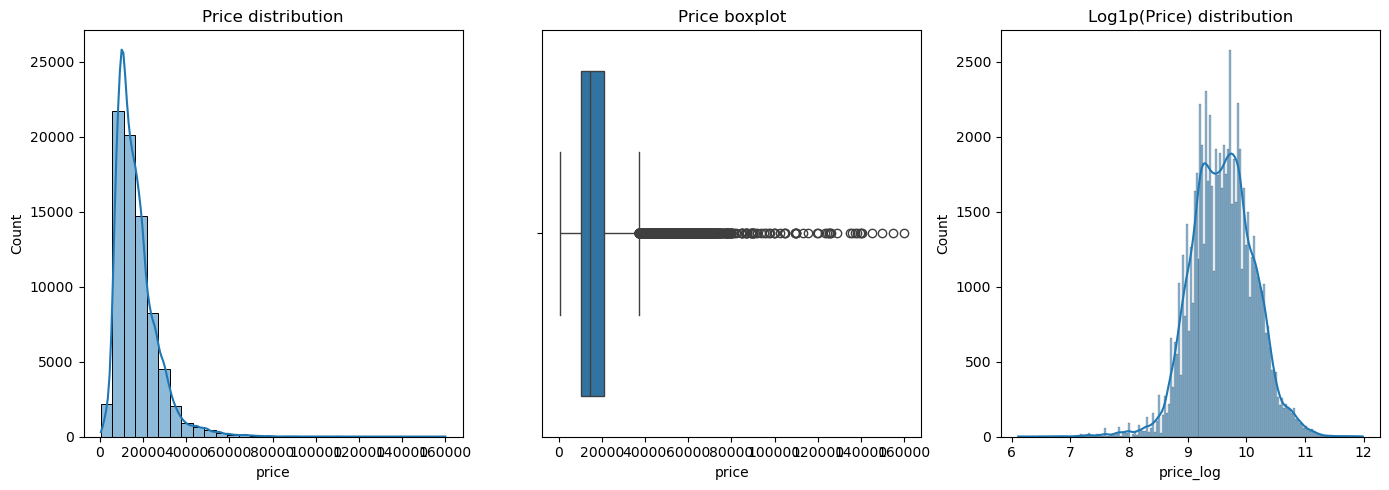

In [22]:
# Distribution & Transform
train['price_log'] = np.log1p(train['price'])

# Statistics
# Calculate skewness, which measures how asymmetric the data distribution is
print("Price skew:", train['price'].skew().round(3)) 
print("Log(price) skew:", train['price_log'].skew().round(3))

# Plots
fig, axes = plt.subplots(1,3, figsize=(14,5))
sns.histplot(train['price'], bins=30, ax=axes[0], kde=True)

axes[0].set_title('Price distribution')
sns.boxplot(x=train['price'], ax=axes[1])
axes[1].set_title('Price boxplot')

# Also plot log-price
sns.histplot(train['price_log'], ax=axes[2], kde=True)
axes[2].set_title('Log1p(Price) distribution')

plt.tight_layout()
plt.show()

The distribution of Price is highly right-skewed, with most observations concentrated at lower values and a long tail of high prices, as shown in both the histogram and boxplot. This indicates the presence of several extreme values (outliers) and a non-normal distribution, which could negatively affect modeling performance if used directly.

With the application of the logarithmic transformation, the distribution becomes much more symmetric and closer to a normal shape. This transformation reduces the impact of extreme values, stabilizes the variance, and facilitates the use of linear models and other statistical methods that assume normality. Additionally, it allows for interpreting model results in terms of percentage changes rather than absolute price differences, which is more meaningful in most economic and financial contexts.

<a class="anchor" id="5_4_6">

### **5.4.6** Descriptive Statistics and Visualizations

[Back to TOP](#top)
</a>

This section begins by categorizing the features into metric (discrete and continuous) and non-metric types. Subsequently, the dataset's main characteristics are summarized using descriptive statistics and visualizations. This process is crucial for understanding distributions, trends, and potential anomalies, providing insights that guide further analysis and modeling decisions.

NOTE: As established in section 5.1, the feature PaintQuality% is excluded from the descriptive statistics and visualizations below.

In [26]:
# Separate the features
metric_features = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize','previousOwners']
non_metric_features = ['brand', 'model', 'transmission', 'fuelType', 'hasDamage']

continuous_features = ['price', 'mileage', 'tax', 'mpg', 'engineSize']
discrete_features = ['year', 'previousOwners']

# Organize the new lists in a table to better visualize them
data = list(zip_longest(
    metric_features,
    non_metric_features,
    continuous_features,
    discrete_features,
    fillvalue=""
))

headers = [
    "Metric Features",
    "Non-Metric Features",
    "Continuous Features",
    "Discrete Features"
]

df_table = pd.DataFrame(data, columns=headers)
print(df_table.to_string(index=False))


Metric Features Non-Metric Features Continuous Features Discrete Features
           year               brand               price              year
          price               model             mileage    previousOwners
        mileage        transmission                 tax                  
            tax            fuelType                 mpg                  
            mpg           hasDamage          engineSize                  
     engineSize                                                          
 previousOwners                                                          


#### **Histograms**

Histograms are used to examine the distribution of continuous features. These plots allow for visualizing the shape of the data, detect skewness, and identifying potential outliers or patterns in the feature values.

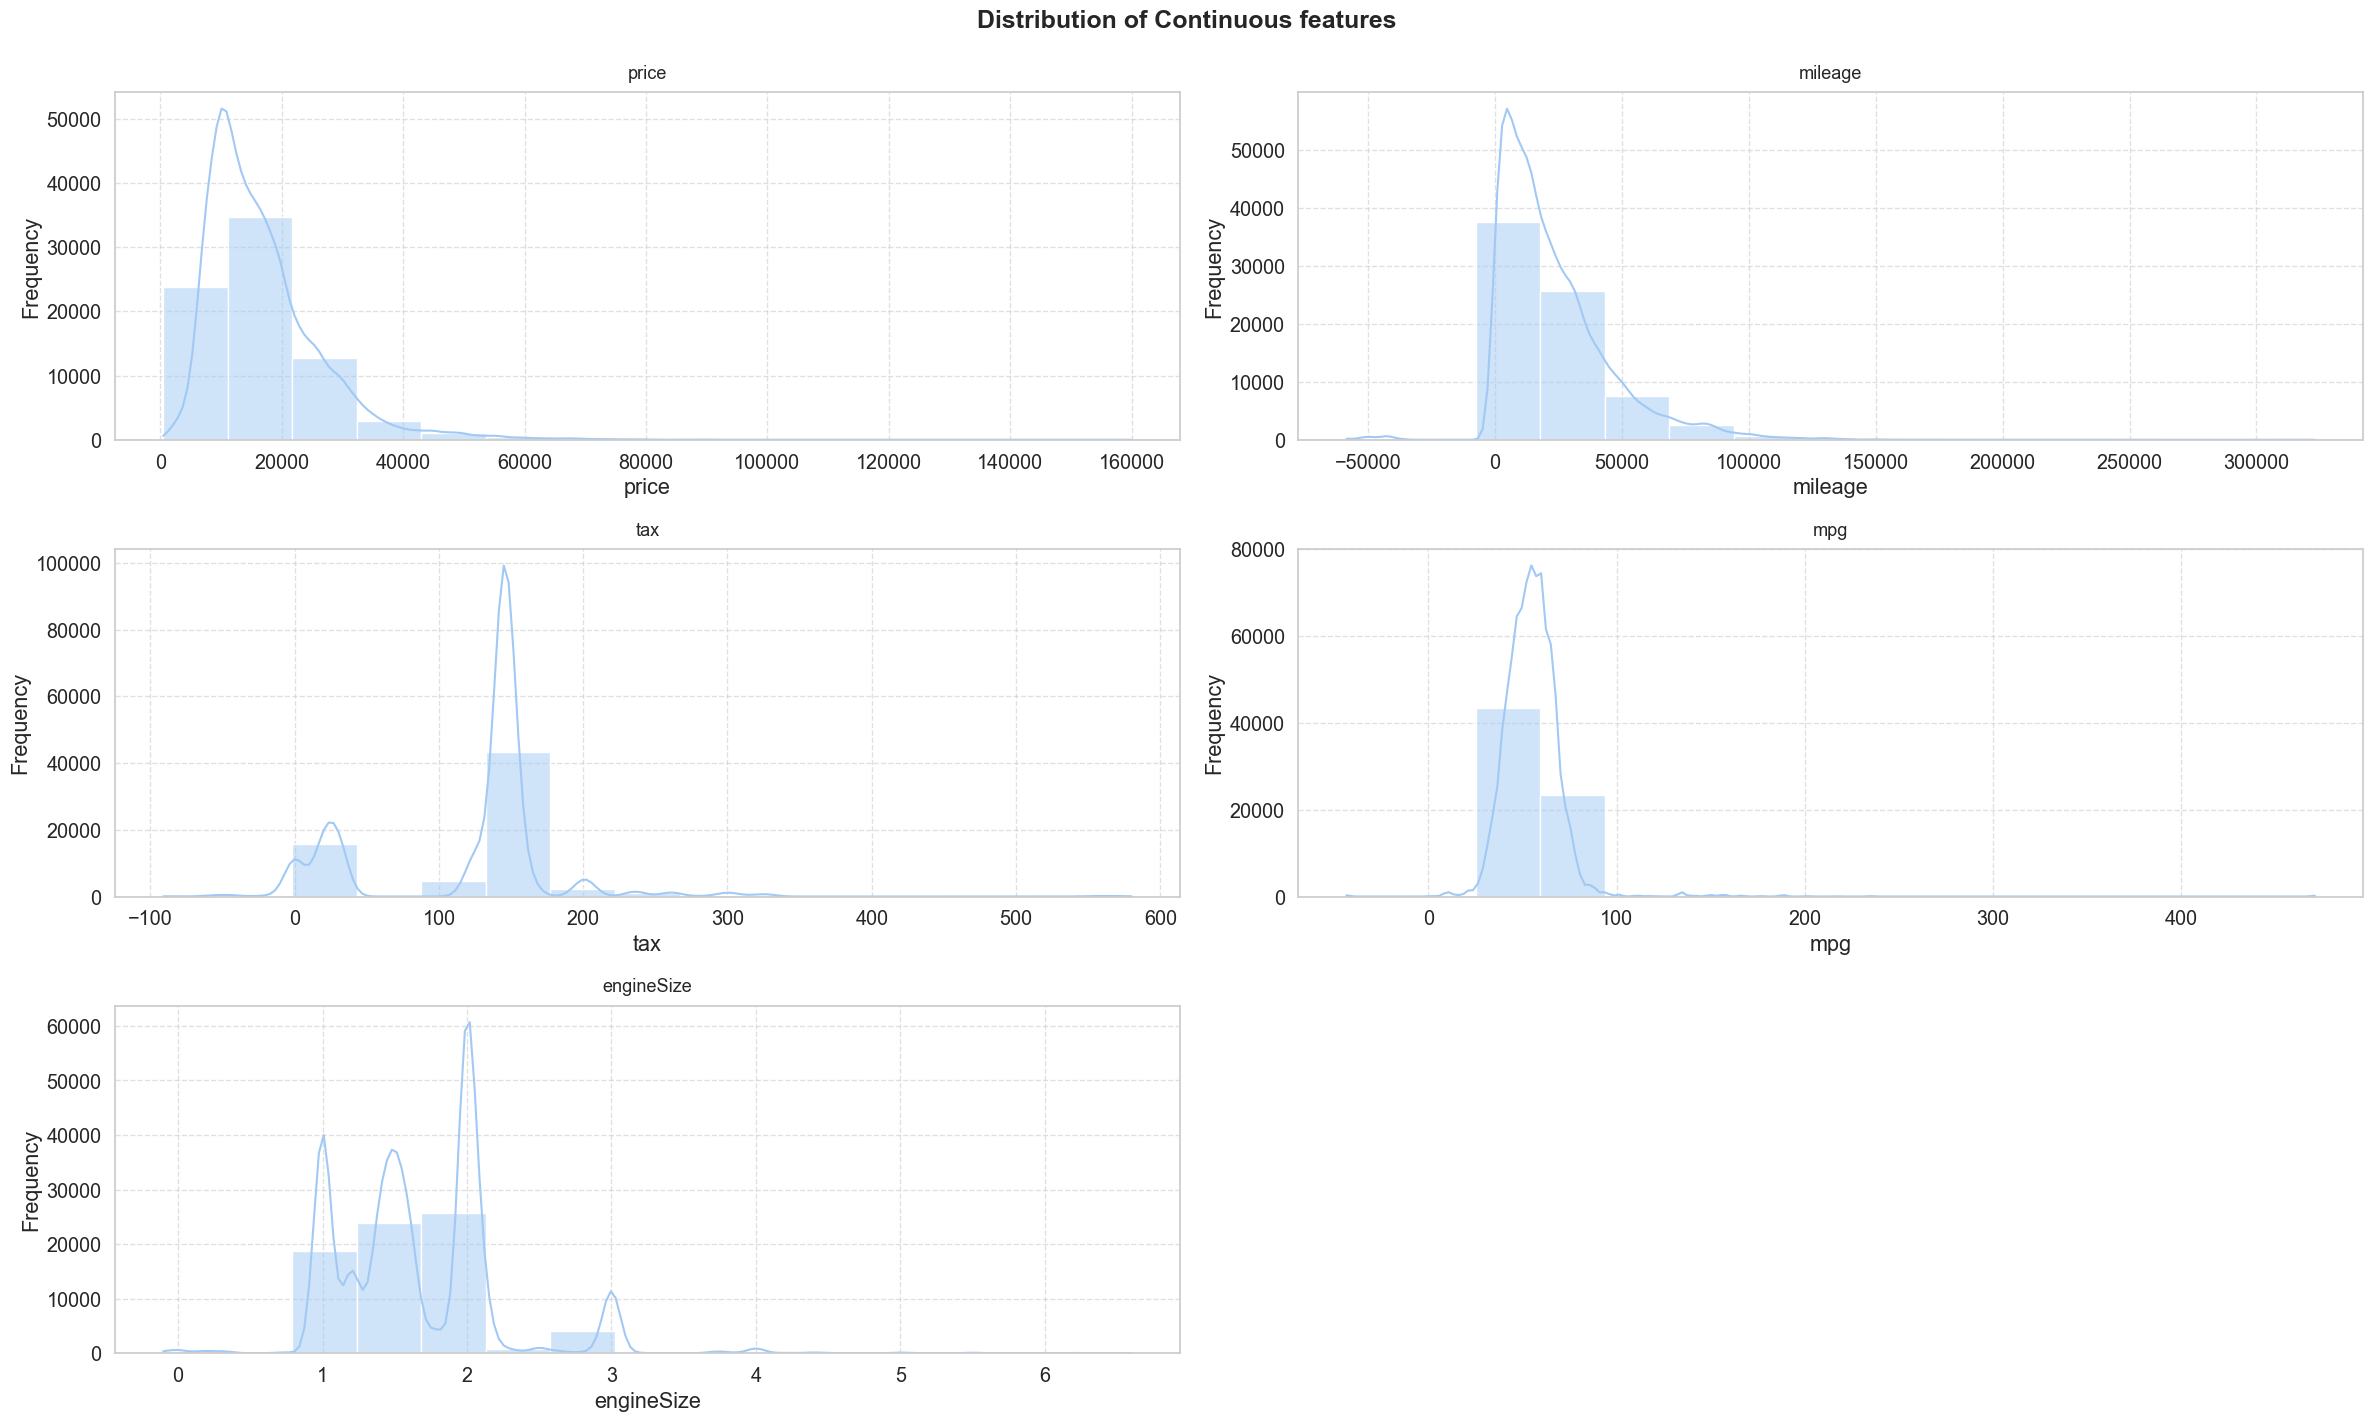

In [28]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 3, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 15))

# Plot data
# Iterate across axes objects and associate each histogram
for ax, feat in zip(axes.flatten(), continuous_features):
    kde_flag = True
    sns.histplot(data=train, x=feat, bins=15, kde=kde_flag, ax=ax)
    ax.set_title(feat, fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.6)

# Turn off unused subplots
for ax in axes.flatten()[len(continuous_features):]:
    ax.axis('off')

# General Layout
fig.suptitle("Distribution of Continuous features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


Based on the evaluation of the histograms, it is possible to state that:

`Price` - The distribution is strongly right-skewed, most cars are low or mid-priced, but a few luxury vehicles inflate the tail. Some prices are extreme outliers, possibly due to rare high-end models. From here we can say that the market is dominated by affordable vehicles.

`Mileage` - Also right-skewed, which is expected. Most used cars have moderate mileage, and a few have very high values. The histogram visually confirms the presence of erroneous negative values.

`Tax` - Sharp peak around a specific value (≈150–200), indicating standardized taxation rates for most vehicles. Some negative or zero values are also noticed.

`Mpg` - Distribution shows that most cars cluster around 20 to 90 miles per gallon , with few very high or very low values, the negative values being incorrect.

`EngineSize` - Multiple peaks, possibly due to different engine categories (1.0L, 1.5L, 2.0L, etc.). The pattern may reflect distinct market segments.

#### **BarPlots**

Bar plots are used to examine the distribution of discrete features. These graphs facilitate the visualization of the data's shape, allowing for the detection of skewness, potential outliers and specific patterns within the feature values.

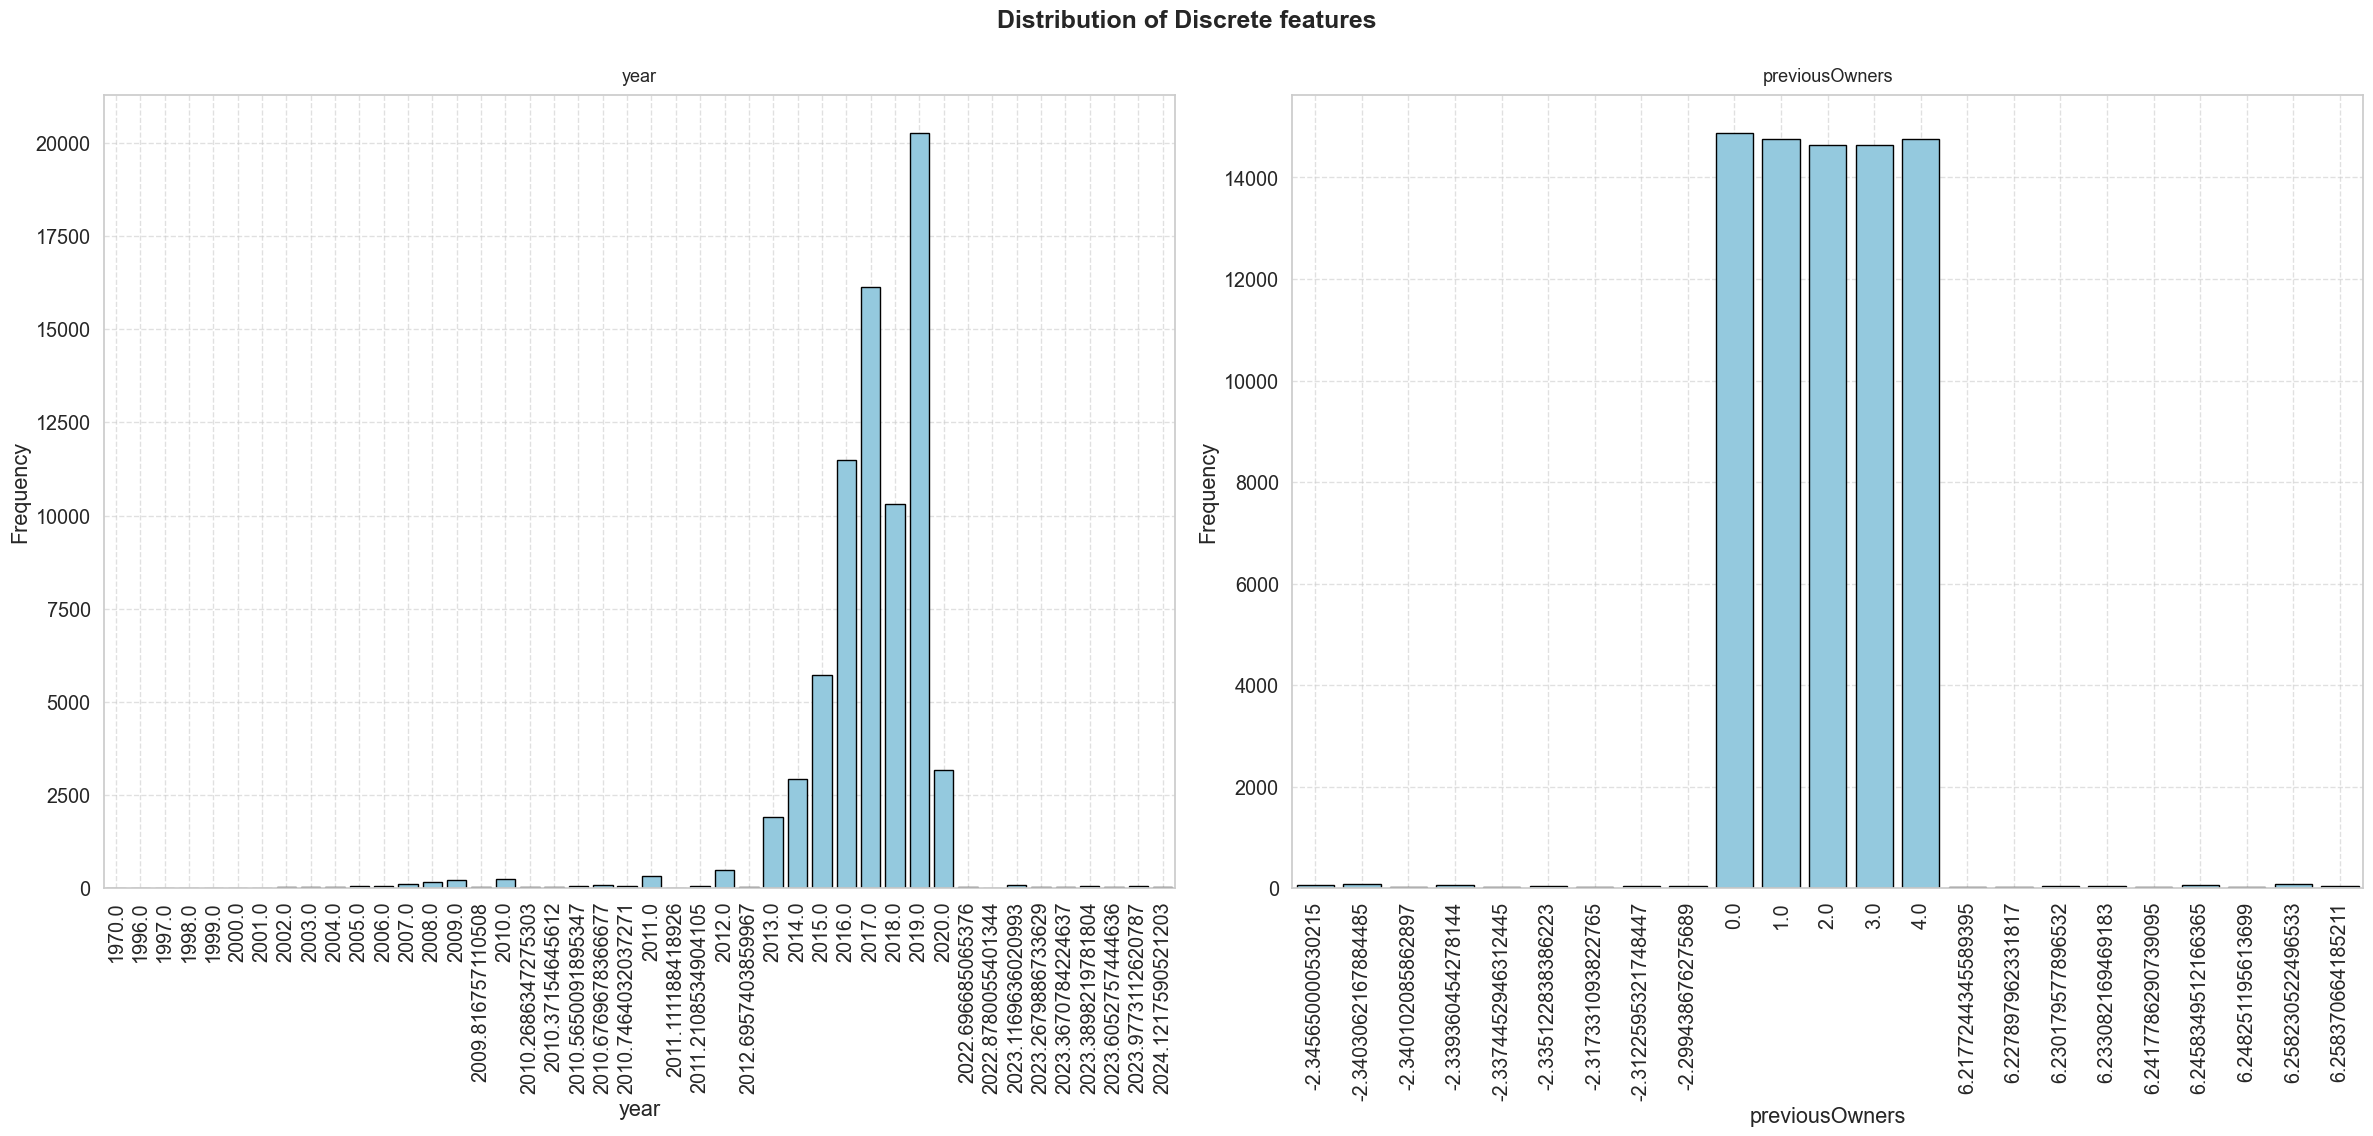

In [29]:
# General settings
sns.set(style="whitegrid", palette="pastel", font_scale=1.3)

sp_rows, sp_cols = 1, 2
fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(24, 12))

# Plot data
for ax, feat in zip(axes.flatten(), discrete_features):
    sns.countplot(data=train, x=feat, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f"{feat}", fontsize=13, pad=10)
    ax.set_ylabel("Frequency")
    ax.set_xlabel(feat)
    ax.tick_params(axis='x', rotation=90) # Rotate x-axis labels for better readability
    ax.grid(True, linestyle="--", alpha=0.6)

fig.suptitle("Distribution of Discrete features", fontsize=18, fontweight='bold', y=0.95)
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


Based on the visualization of the discrete features, the following patterns are observed:

`Year` - The distribution is heavily skewed towards recent years, with the majority of vehicles registered between 2015 and 2020. This indicates a dataset dominated by modern cars. However, the presence of outliers (extremely old cars or potential errors) is visible in the lower tail.

`PreviousOwners` - The plot visually confirms the data inconsistencies previously identified. The x-axis explicitly displays floating-point numbers and negative values, which are logically impossible for a count of owners. Despite these errors, it is evident that the majority of the valid data is concentrated between 0 and 4 owners.

#### **Boxplots** (Outliers Detection)

Boxplots are employed to visualize the spread and variability of numerical features. These plots highlight the median, quartiles, and outliers, facilitating the detection of unusual values and the understanding of the overall data distribution.

Given that boxplots are a recurrent visualization throughout this analysis, a custom function was developed and stored in an external .py file. This ensures that all plots maintain a consistent structure and styling.

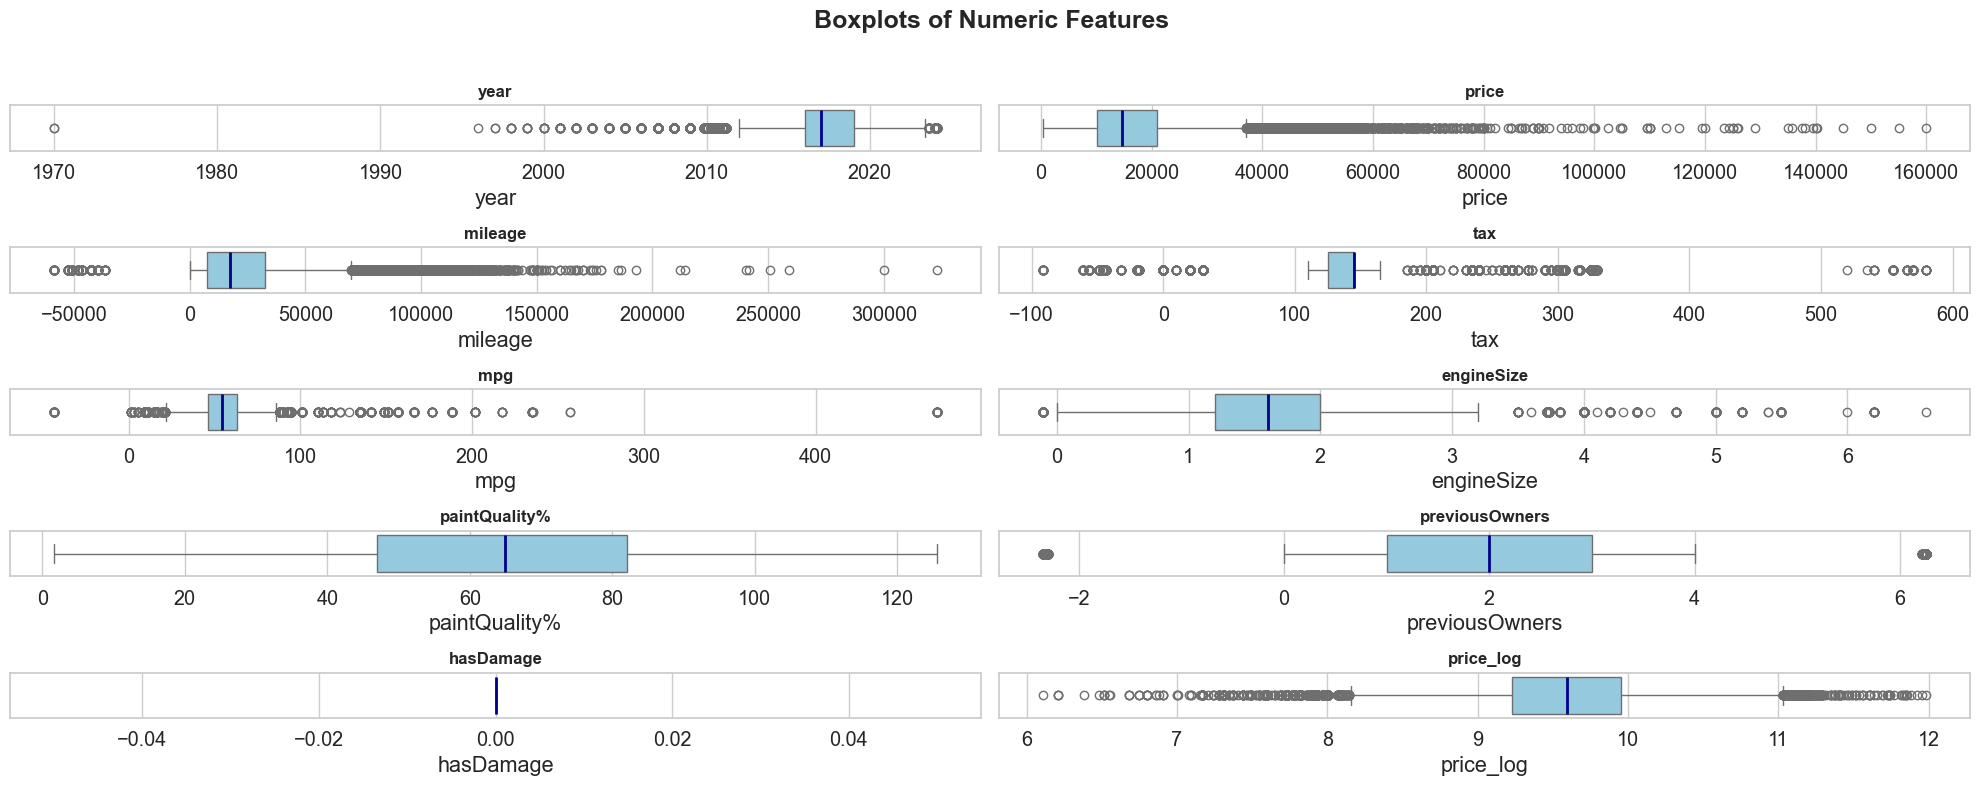

In [30]:
# Call the function
create_boxplots(train)

Based on the boxplots shown above, it can be observed that:

`Year` - The distribution is left-skewed, with a wide range of outliers from the mid-1990s to the early 2000s. We can also clearly see invalid values appearing after the year 2020.

`Price`- This boxplot is right-skewed, with a large proportion of outliers ranging approximately from £40,000 up to £160,000, showing a wide interval compared to the main body of the data.

`Mileage` - Mileage displays a positively skewed distribution with several high-value outliers and a negative value appears in the data.

`Tax`- The distribution is concentrated around specific values but includes some outliers. It has also negative values what makes no sense.

`Mpg`- The distribution is mostly concentrated but includes both low and very high outliers. Some extreme values, such us those above 200 mpg are unrealistic and will be validated. Has also negative values that make no sense and represent errors that need to be treated later.

`EngineSize`- The boxplot shows most engines concentrated between 1.0 and 2.0L, with several larger values appearing as outliers.

`PreviousOwners`- The distribution is concentrated between 1 and 3 owners, with a few outliers, including cars with more than 6 owners and some negative values.

<a class="anchor" id="5_5">

## **5.5** Bivariate Analysis
[Back to TOP](#top)
</a>

Here we study the relationship between two features at a time, mainly between the features and the target feature. This analysis helps us understand how each feature might influence the target and whether any correlations exist.

<a class="anchor" id="5_5_1">

### **5.5.1** GroupBy Analysis
[Back to TOP](#top)
</a>


We use groupby operations to summarize and compare data across some different categories. This allows us to examine how numerical features vary between groups, identify patterns, and explore relationships that may be important for modeling.

In [ ]:
print(train.groupby('hasDamage')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('year')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('previousOwners')['price'].mean())

print('--------------------------------------------------------')

print(train.groupby('Brand')['price'].mean())


hasDamage
0.0    16883.327287
Name: price, dtype: float64
--------------------------------------------------------
year
1970.000000    17747.000000
1996.000000     3000.000000
1997.000000     6972.500000
1998.000000    10183.800000
1999.000000     3986.000000
2000.000000     3869.166667
2001.000000     4401.000000
2002.000000     3206.920000
2003.000000     3452.517241
2004.000000     4179.914286
2005.000000     3007.468750
2006.000000     3958.580645
2007.000000     3454.910569
2008.000000     3913.069620
2009.000000     4141.008772
2009.816757    19686.486486
2010.000000     5016.514523
2010.268635    12568.100000
2010.371546    24268.114286
2010.565009    11370.425532
2010.676968    12834.268293
2010.746403    18257.810345
2011.000000     6771.940252
2011.111188    13038.466667
2011.210853    22981.640000
2012.000000     7601.456067
2012.695740    12633.095238
2013.000000     8503.491062
2014.000000    10025.783276
2015.000000    11654.296180
2016.000000    13357.350287
2017.000000 

The mean of price of the cars without damage is approximately 16883. It would be interesting to compare with the one's with damage (1's), but we don't have any information about them.

It's also possible to verify that the price varies depending on the year of manufacture of the cars. This is, the older the car, the cheaper it is.

For the number of previous Owners, we don't see major differences on the average price. 

Finally, when analysing the average price per brand, we can already see some differences between brands, per example, Hyundai's cars have lower average than Audi's cars.


<a class="anchor" id="5_5_2">

### **5.5.2** Correlation Matrix (Heatmap)
[Back to TOP](#top)
</a>

This section is quite important. We analyze the relationships between numerical features using correlation measures. This helps us identify which featires are strongly related, detect potential multicollinearity, and understand how features may influence each other or the target feature.

In [ ]:
numeric_features = train[['year', 'mileage', 'price', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']]
numeric_features.corr(method="pearson").round(3)

,year,mileage,price,tax,mpg,engineSize,paintQuality%,previousOwners
year,1.000,-0.669,0.476,0.179,-0.123,-0.038,0.004,0.000
mileage,-0.669,1.000,-0.405,-0.202,0.167,0.099,-0.001,0.002
price,0.476,-0.405,1.000,0.297,-0.286,0.612,0.000,-0.000
tax,0.179,-0.202,0.297,1.000,-0.419,0.257,0.006,0.003
mpg,-0.123,0.167,-0.286,-0.419,1.000,-0.227,-0.003,-0.001
engineSize,-0.038,0.099,0.612,0.257,-0.227,1.000,0.005,0.001
paintQuality%,0.004,-0.001,0.000,0.006,-0.003,0.005,1.000,-0.006
previousOwners,0.000,0.002,-0.000,0.003,-0.001,0.001,-0.006,1.000


From the code before it's difficult to get conclusions. We will visualize this matrix using a heatmap. The heatmap provides an intuitive overview of the strength and direction of relationships, making it easier to identify strongly correlated features and patterns in the data.

Here we use heatmaps based on Pearson and Spearman correlation coefficients. Pearson correlation measures linear relationships, while Spearman correlation captures monotonic relationships. 

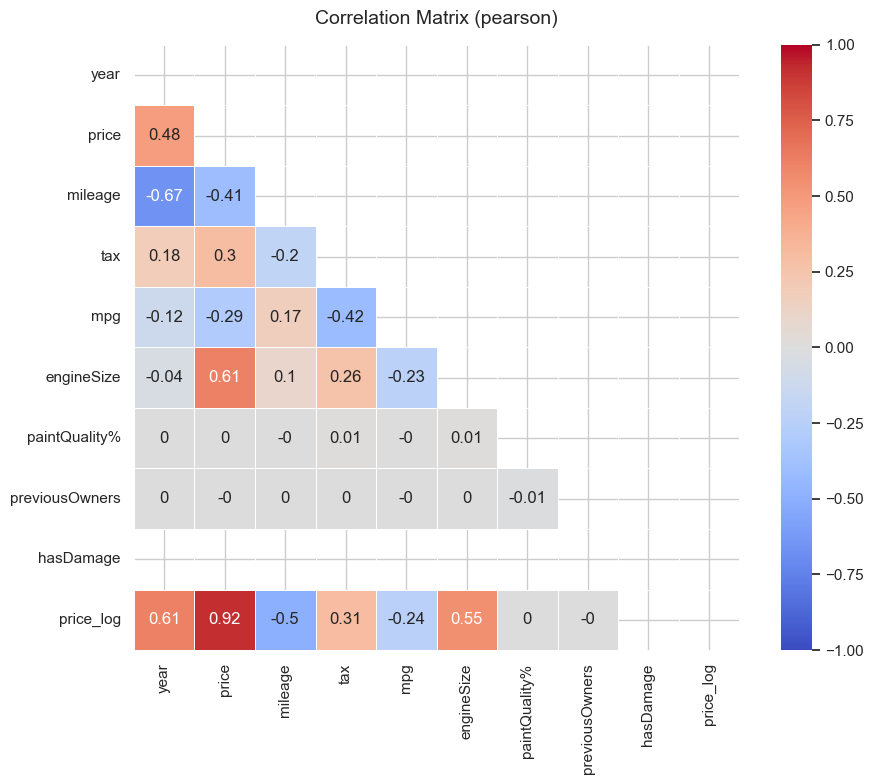

In [ ]:
create_heatmap(train, method="pearson", figsize=(10, 8))

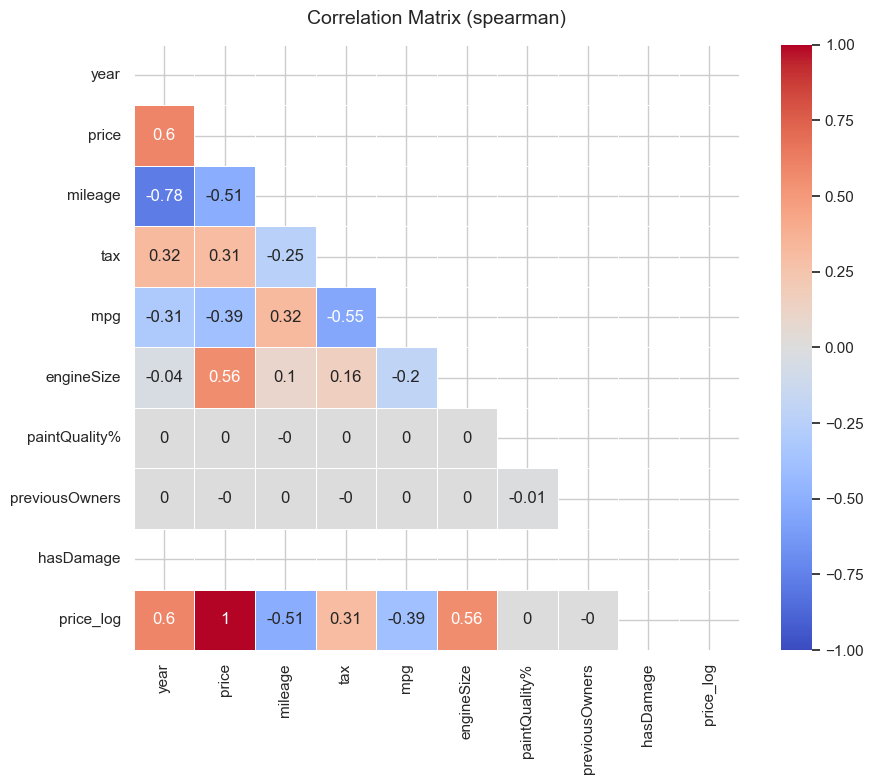

In [ ]:
create_heatmap(train, method="spearman")

Based on the correlation analysis using both spearman and pearson methods, we can identify the potential impact of our numerical features on the target variable ("price"):

- year, mileage and engineSize are likely to be the most important predictors.
- tax and mpg might provide secondary predictive power.
- previousOwners and hasDamage appears to offer limited utility in its current state, unless further cleaned or reinterpreted.

<a class="anchor" id="5_5_3">

### **5.5.3** Pairplot Analysis
[Back to TOP](#top)
</a>

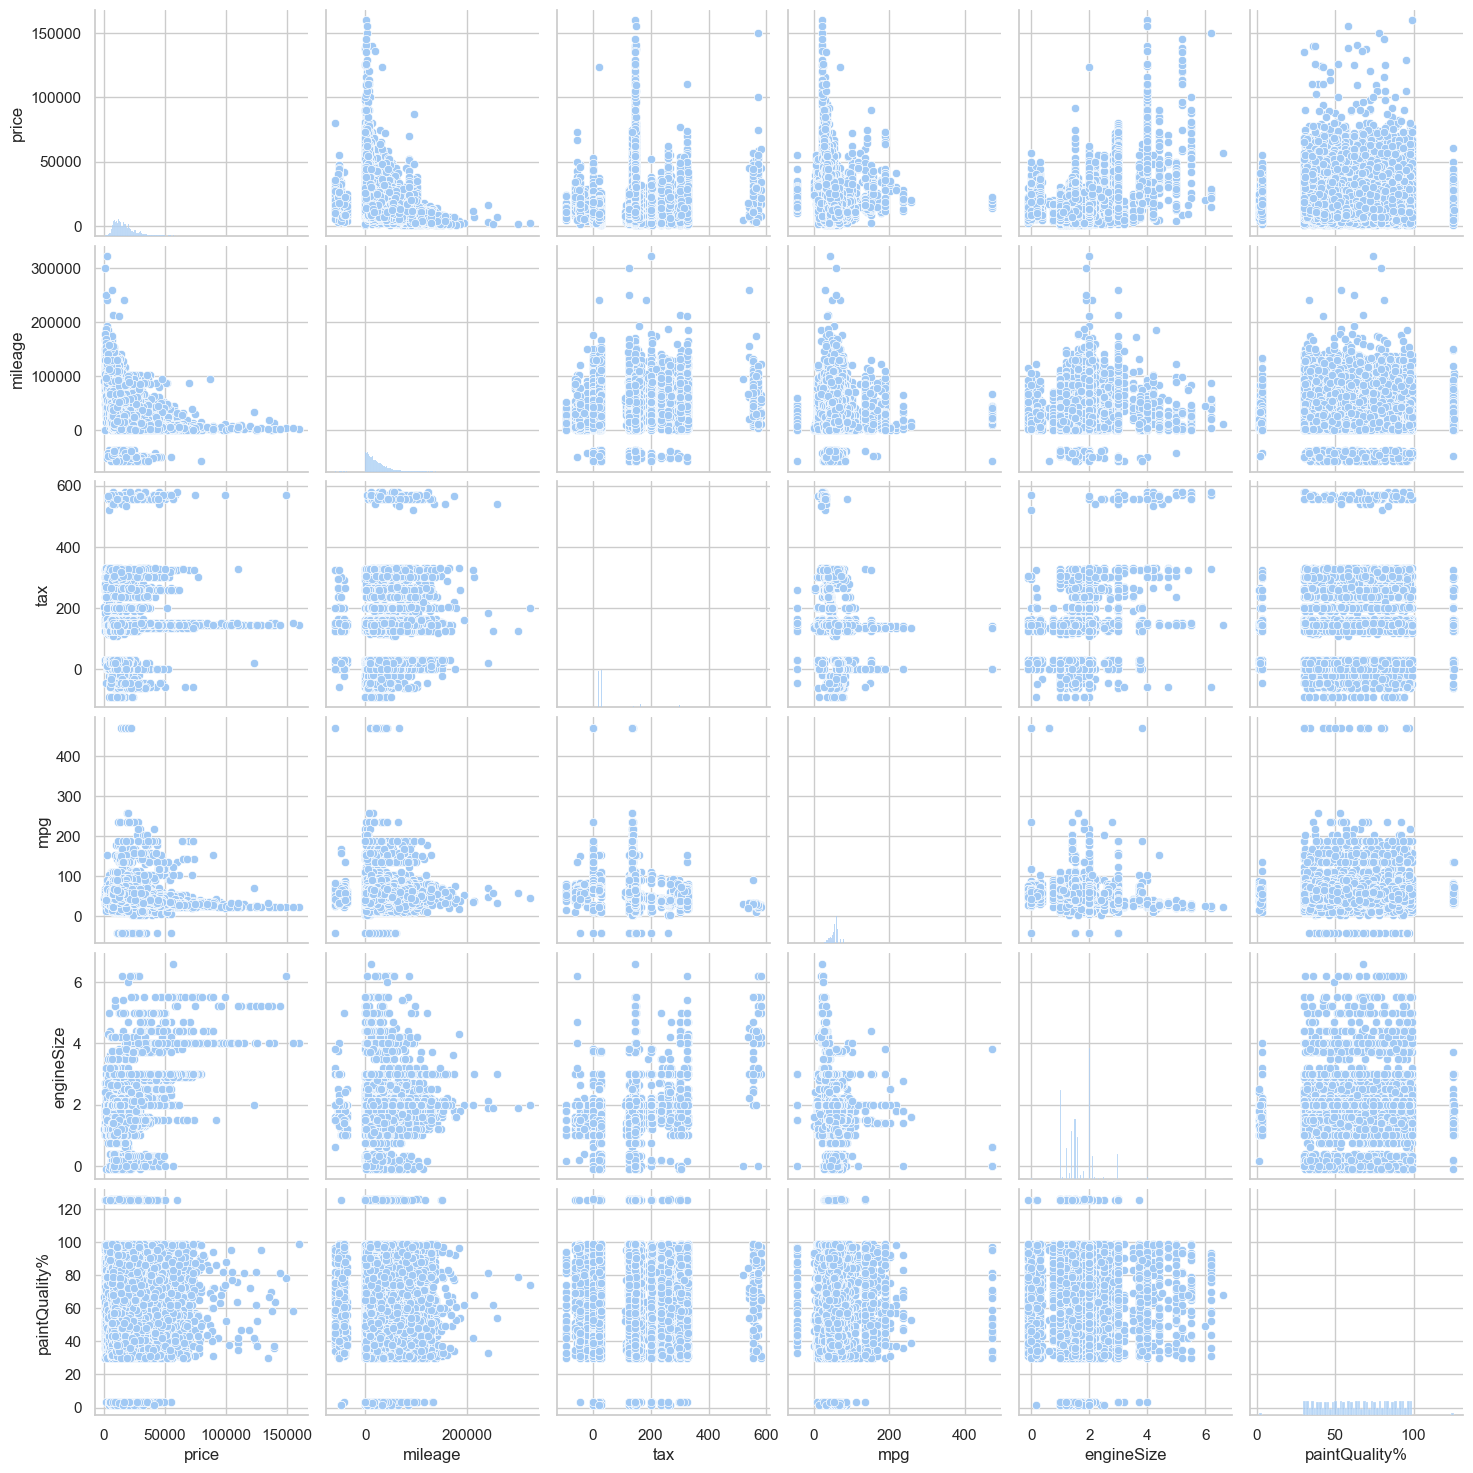

In [ ]:
sns.pairplot(train[continuous_features])

<a class="anchor" id="5_6">

## **5.6** Multivariate Analysis
[Back to TOP](#top)
</a>

In this part, we explore the interactions between several features simultaneously. The goal is to identify more complex relationships and combined effects that may not be visible when analyzing features separately.

<a class="anchor" id="5_6_1">

### **5.6.1** Scatterplot 3D
[Back to TOP](#top)
</a>

The 3D scatter plot visualizes the relationship between a car’s price, year of registration, and mileage.
Each point represents a car, where newer models (higher year values) and those with lower mileage tend to have higher prices.
This graph helps identify depreciation patterns, as mileage increases or the car becomes older, its value generally decreases.
It provides a clear, three-dimensional view of how these features interact to influence car pricing.

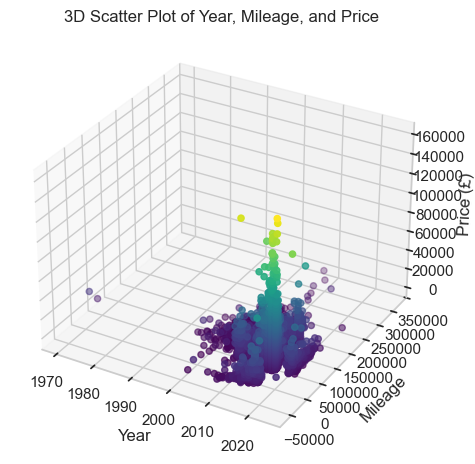

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(train['year'], train['mileage'], train['price'], c=train['price'], cmap='viridis')
ax.set_xlabel('Year')
ax.set_ylabel('Mileage')
ax.set_zlabel('Price (£)')

plt.title('3D Scatter Plot of Year, Mileage, and Price')
plt.tight_layout()
plt.show()


The three-dimensional analysis of Year, Mileage, and Price demonstrates that vehicle depreciation follows a cone-shaped pattern within the valid data range. Recent models (2015-2020) and low mileage vehicles are concentrated at the top of the price spectrum, while older vehicles converge toward a minimum value floor regardless of accumulated use.

The pattern reveals three distinct depreciation dynamics: extreme sensitivity to mileage in recent vehicles, moderate depreciation in intermediate-age cars, and price stagnation in older models. Crucially, Year and Mileage do not act independently but through a multiplicative interaction, where the impact of mileage is amplified in newer cars and negligible in older ones.

This explains the limitation of simple linear models and suggests that interaction features and logarithmic transformations are necessary to improve predictive accuracy. Finally, the visualization confirms the presence of erroneous data points (years > 2020) which do not fit the depreciation logic and must be removed rather than treated as statistical outliers.

<a class="anchor" id="5_6_2">

### **5.6.2** Scatter Matrix
[Back to TOP](#top)
</a>

Illustrates the relationships between continuous features (price, year, mileage, engine size, and mpg) while distinguishing cars by fuel type.
Each scatter plot shows how two features interact, and the diagonal plots display their individual distributions.
From this visualization, we can identify patterns such as newer cars with lower mileage tending to have higher prices, or how fuel type influences fuel efficiency (mpg) and engine size.
Overall, the pairplot provides a comprehensive multivariate overview of how these core features relate to each other across different fuel categories.

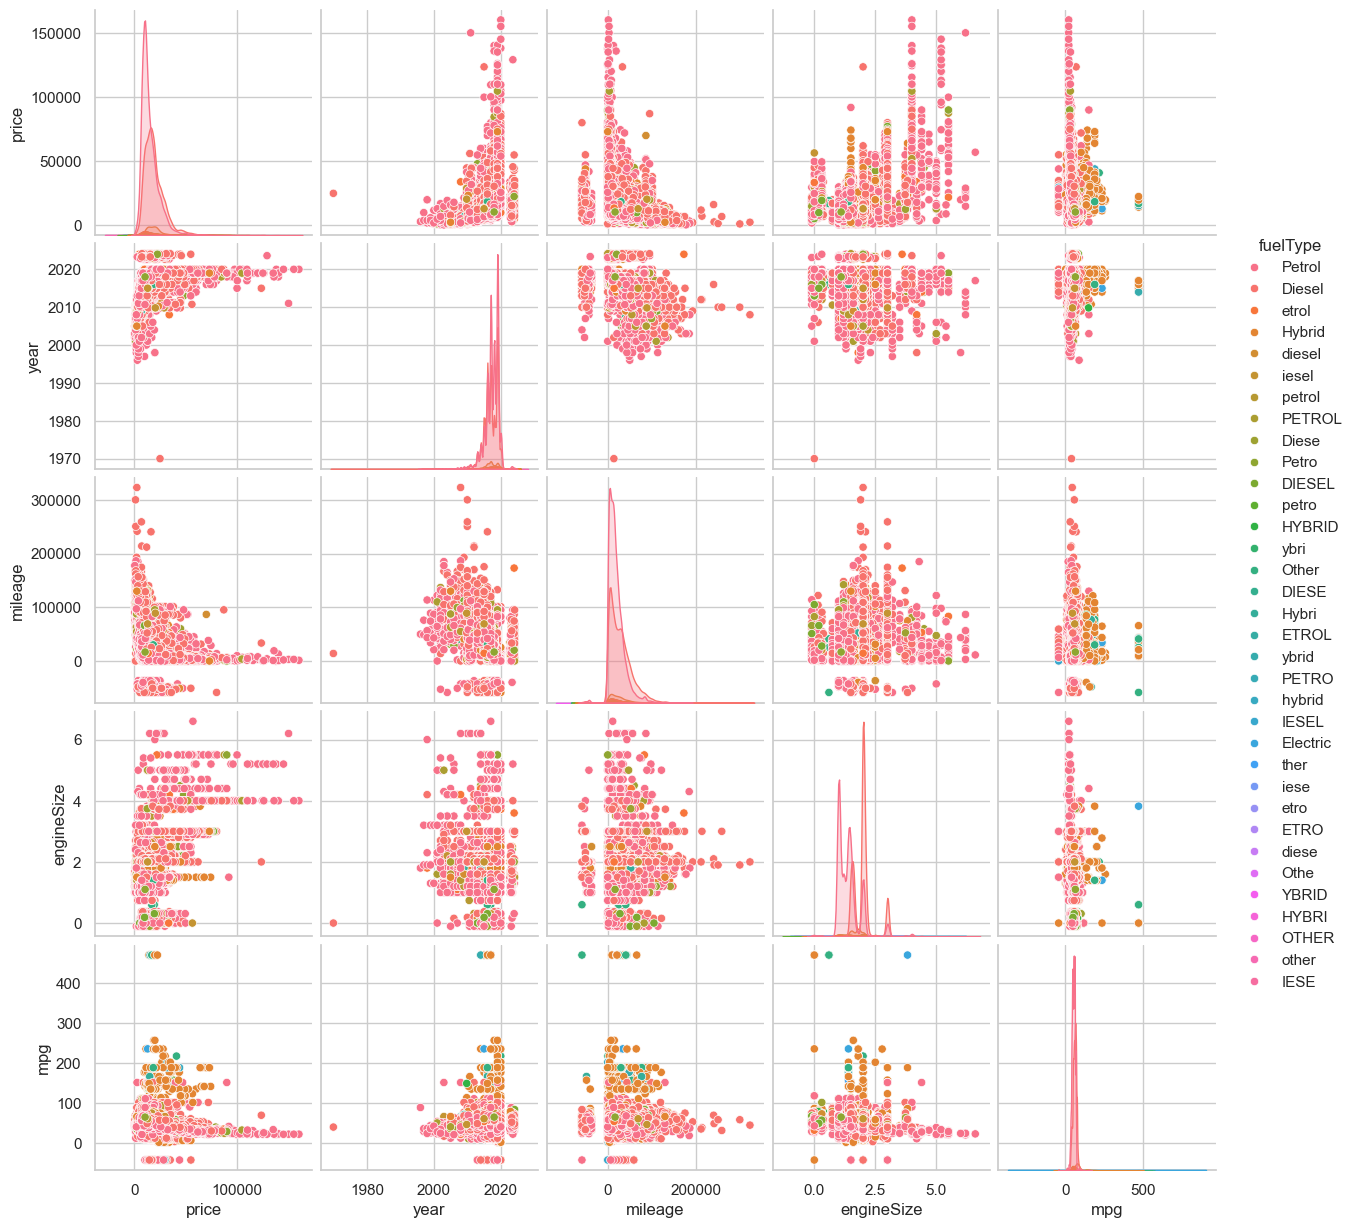

In [ ]:
sns.pairplot(train, vars=['price', 'year', 'mileage', 'engineSize', 'mpg'], hue='fuelType')
plt.show()

The pairplot reveals strong relationships between vehicle price and features such as year, mileage, and engine size. It shows that newer cars with lower mileage tend to have higher prices, while vehicles with larger engines are generally more expensive but less fuel-efficient (lower mpg). There is also a clear negative correlation between engine size and fuel efficiency, indicating that bigger engines consume more fuel. The fuelType feature shows a predominance of petrol cars, although multiple variations in spelling suggest the need for data standardization. Overall, the dataset displays expected patterns of vehicle valuation but also contains outliers and inconsistencies that should be addressed for more accurate analysis.

<a class="anchor" id="6">

# **6. End of the Notebook**

[Back to TOP](#top)
</a>

The next steps